In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models


mass_sun, radius_sun, newton_G = 1.9884e30, 6.957e8, 6.674e-11
font_model = WD_models.load_model("be", "be", "be", "H")
g_acc = (10**font_model["logg"]) / 100.0
rsun = np.sqrt(font_model["mass_array"] * mass_sun * newton_G / g_acc) / radius_sun

_G_RAD_FUNC = WD_models.interp_xy_z_func(
    x=rsun, y=10**font_model["logteff"],
    z=font_model["mass_array"],
    interp_type="linear",
)

In [2]:
data = pd.read_parquet("../data/merges/wbinary_heintz2022.pqt").query("teff_H > 100")

data.loc[:,"mass_thick"] = _G_RAD_FUNC(data.loc[:, "radius_thick"], data.loc[:, "teff_thick"])
data.loc[:,"mass_mixed"] = _G_RAD_FUNC(data.loc[:, "radius_mixed"], data.loc[:, "teff_mixed"])
data.loc[:,"mass_thin"] = _G_RAD_FUNC(data.loc[:, "radius_thin"], data.loc[:, "teff_thin"])

data["e_Teff"] = 0.5*(data.e_Teff_upper + data.e_Teff_lower)

data["logg_thick"] = np.log10(data["mass_thick"] / (data["radius_thick"]**2)) + 4.437
data["logg_mixed"] = np.log10(data["mass_mixed"] / (data["radius_mixed"]**2)) + 4.437
data["logg_thin"] = np.log10(data["mass_thin"] / (data["radius_thin"]**2)) + 4.437


In [3]:
data["std_teff_thick"] = 100*(data.Teff-data.teff_thick) / data.Teff
data["std_logg_thick"] = 100*(data.Logg-data.logg_thick) / data.Logg

data["std_teff_mixed"] = 100*(data.Teff-data.teff_mixed) / data.Teff
data["std_logg_mixed"] = 100*(data.Logg-data.logg_mixed) / data.Logg

data["std_teff_thin"] = 100*(data.Teff-data.teff_thin) / data.Teff
data["std_logg_thin"] = 100*(data.Logg-data.logg_thin) / data.Logg

In [4]:
thick = data.query("(spectype == 'DA') or (spectype == 'DA:') or (spectype == 'DAH') or (spectype == 'DAZ')")
mixed = data.query("(spectype == 'DAB') or (spectype == 'DBA') or (spectype == 'DBA:')" \
"or (spectype == 'DC' and Teff < 11000 and Teff > 5500)")
thin = data.query("not ((spectype == 'DA') or (spectype == 'DA:') or (spectype == 'DAH') or (spectype == 'DAZ'))" \
"and not ((spectype == 'DAB') or (spectype == 'DBA') or (spectype == 'DBA:')" \
"or (spectype == 'DC' and Teff < 11000 and Teff > 5500))")

Text(0.05, 0.25, '$\\langle \\Delta T_\\mathrm{eff} \\rangle = -2.27\\%$\n\n$\\langle \\Delta log g \\rangle = -1.15\\%$')

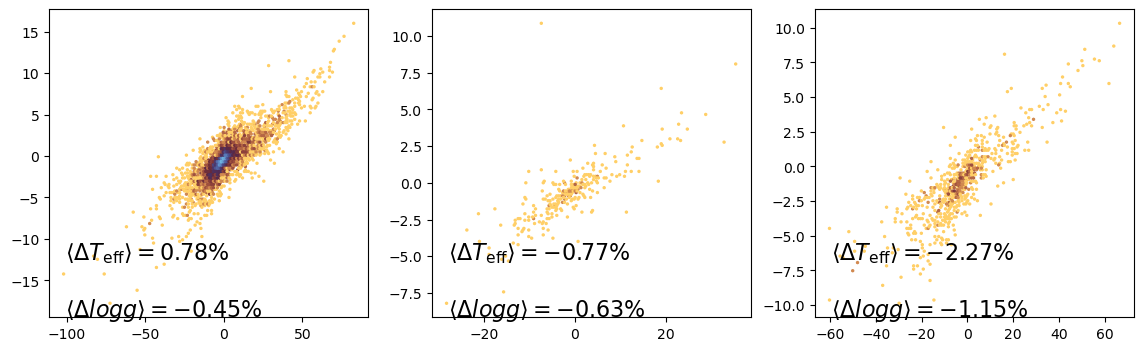

In [5]:
fig, ax = plt.subplots(ncols=3, figsize=(14, 4))
ax[0].hexbin(thick.std_teff_thick, thick.std_logg_thick, bins="log", 
             cmap="managua", gridsize=150, vmin=1, vmax=1e2)
ax[0].text(0.05, 0.25,
    rf"$\langle \Delta T_\mathrm{{eff}} \rangle = "
    rf"{np.mean(thick.std_teff_thick):1.2f}\%$"
    "\n\n"
    rf"$\langle \Delta log g \rangle = "
    rf"{np.mean(thick.std_logg_thick):1.2f}\%$",
    color="k", ha="left", va="top", fontsize=16,
    transform=ax[0].transAxes
)

ax[1].hexbin(mixed.std_teff_mixed, mixed.std_logg_mixed, bins="log", 
             cmap="managua", gridsize=150, vmin=1, vmax=1e2)
ax[1].text(0.05, 0.25,
    rf"$\langle \Delta T_\mathrm{{eff}} \rangle = "
    rf"{np.mean(mixed.std_teff_mixed):1.2f}\%$"
    "\n\n"
    rf"$\langle \Delta log g \rangle = "
    rf"{np.mean(mixed.std_logg_mixed):1.2f}\%$",
    color="k", ha="left", va="top", fontsize=16,
    transform=ax[1].transAxes
)

ax[2].hexbin(thin.std_teff_thin, thin.std_logg_thin, bins="log", 
             cmap="managua", gridsize=150, vmin=1, vmax=1e2)
ax[2].text(0.05, 0.25,
    rf"$\langle \Delta T_\mathrm{{eff}} \rangle = "
    rf"{np.mean(thin.std_teff_thin):1.2f}\%$"
    "\n\n"
    rf"$\langle \Delta log g \rangle = "
    rf"{np.mean(thin.std_logg_thin):1.2f}\%$",
    color="k", ha="left", va="top", fontsize=16,
    transform=ax[2].transAxes
)